# 01 · Análisis exploratorio (EDA) — comentarios de YouTube

**Objetivo**: entender el dataset *antes* de modelar: qué etiquetas tiene, qué tan fiables son,
cómo es el texto y qué riesgos plantea para el modelo (tamaño, ruido, sesgo por vídeo).

Estructura:
1. Visión general y calidad básica
2. Etiquetas: balance y solapamiento
3. Longitud y forma del texto
4. Vocabulario: qué palabras distinguen el odio
5. Leer comentarios reales
6. Efecto del vídeo
7. Conclusiones y decisiones para el modelado


In [1]:
import re, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.feature_extraction.text import CountVectorizer
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 160)

from hatedet.data.loader import load_raw_comments
from hatedet.data.schema import LABEL_COLUMNS, TARGET_COLUMN, TEXT_COLUMN, VIDEO_ID_COLUMN

df = load_raw_comments(Path("../data/raw/youtoxic_english_1000.csv"))
print(df.shape)
df.head(3)

(997, 15)


,CommentId,VideoId,Text,IsToxic,IsAbusive,IsThreat,IsProvocative,IsObscene,IsHatespeech,IsRacist,IsNationalist,IsSexist,IsHomophobic,IsReligiousHate,IsRadicalism
0,Ugg2KwwX0V8-aXgCoAEC,04kJtp6pVXI,"If only people would just take a step back and not make this case about them, because it wasn't about anyone except the two people in that situation. To lu...",False,False,False,False,False,False,False,False,False,False,False,False
1,Ugg2s5AzSPioEXgCoAEC,04kJtp6pVXI,Law enforcement is not trained to shoot to apprehend. They are trained to shoot to kill. And I thank Wilson for killing that punk bitch.,True,True,False,False,False,False,False,False,False,False,False,False
2,Ugg3dWTOxryFfHgCoAEC,04kJtp6pVXI,\nDont you reckon them 'black lives matter' banners being held by white cunts is kinda patronizing and ironically racist. could they have not come up with ...,True,True,False,False,True,False,False,False,False,False,False,False


## 1. Visión general y calidad básica

In [2]:
print("Filas (tras quitar 3 duplicados exactos):", len(df))
print("Vídeos:", df[VIDEO_ID_COLUMN].nunique())
print("Nulos:", int(df.isna().sum().sum()))
print("VideoId corrupto ('#NAME?'):", int((df[VIDEO_ID_COLUMN] == "#NAME?").sum()), "filas")
print("Comentarios sin ninguna etiqueta activa:", int((df[LABEL_COLUMNS].sum(axis=1) == 0).sum()))

Filas (tras quitar 3 duplicados exactos): 997
Vídeos: 13
Nulos: 0
VideoId corrupto ('#NAME?'): 16 filas
Comentarios sin ninguna etiqueta activa: 538


## 2. Etiquetas: balance y solapamiento

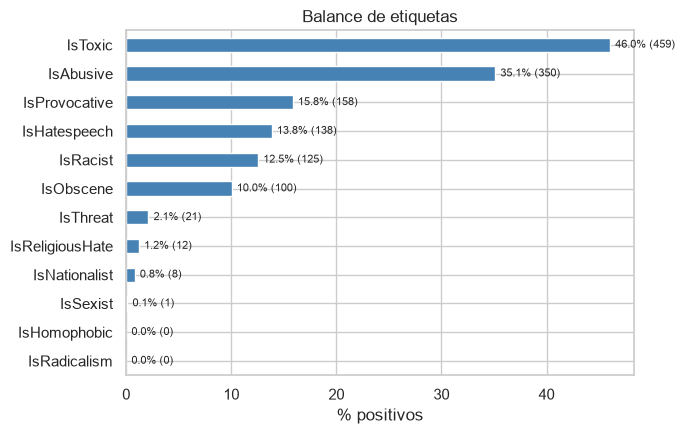

In [3]:
rates = (df[LABEL_COLUMNS].mean() * 100).sort_values()
ax = rates.plot.barh(figsize=(7, 4.5), color="steelblue")
ax.set_xlabel("% positivos"); ax.set_title("Balance de etiquetas")
for i, v in enumerate(rates): ax.text(v + 0.5, i, f"{v:.1f}% ({int(round(v*len(df)/100))})", va="center", fontsize=8)
plt.tight_layout(); plt.show()

Solo 6 etiquetas tienen un volumen razonable. Las demás (`IsHomophobic`, `IsRadicalism`, `IsSexist`,
`IsNationalist`, `IsReligiousHate`) tienen 0–12 positivos: **no se pueden modelar**.

¿Cómo se solapan las etiquetas? Comprobamos si forman una jerarquía (odio ⊂ tóxico, racista ⊂ odio).

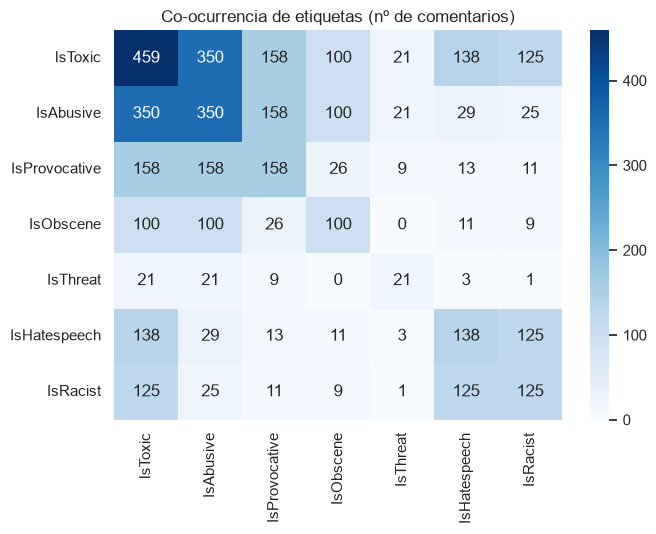

In [4]:
main = ["IsToxic","IsAbusive","IsProvocative","IsObscene","IsThreat","IsHatespeech","IsRacist"]
co = df[main].astype(int).T.dot(df[main].astype(int))
plt.figure(figsize=(7, 5.5))
sns.heatmap(co, annot=True, fmt="d", cmap="Blues")
plt.title("Co-ocurrencia de etiquetas (nº de comentarios)"); plt.tight_layout(); plt.show()

In [5]:
ct = pd.crosstab(df["IsHatespeech"], df["IsToxic"], rownames=["IsHatespeech"], colnames=["IsToxic"])
print(ct)
print()
print("IsHatespeech=True y IsToxic=False:", int(ct.loc[True, False]), "-> inconsistencia si el odio siempre es tóxico")
print("IsHatespeech=True y IsRacist=True :", int(((df.IsHatespeech) & (df.IsRacist)).sum()), "de", int(df.IsHatespeech.sum()))
print("IsRacist=True y IsHatespeech=False:", int(((~df.IsHatespeech) & (df.IsRacist)).sum()))

IsToxic       False  True 
IsHatespeech              
False           538    321
True              0    138

IsHatespeech=True y IsToxic=False: 0 -> inconsistencia si el odio siempre es tóxico
IsHatespeech=True y IsRacist=True : 125 de 138
IsRacist=True y IsHatespeech=False: 0


**Lectura (contra lo que se esperaba)**: las etiquetas **no son ruidosas, son jerárquicas y consistentes**:
todo `IsHatespeech` es también `IsToxic`, y todo `IsRacist` es también `IsHatespeech`. Consecuencia importante:
**el 91% del "odio" (125 de 138) es racismo**. Nuestro target `IsHatespeech` es en la práctica *"racismo en
comentarios sobre un suceso concreto"*, no odio en general. Además, el 54% de los comentarios no tiene ninguna
etiqueta activa.

## 3. Longitud y forma del texto

        chars  words
count   997.0  997.0
mean    186.1   33.9
std     271.0   49.1
min       3.0    1.0
25%      47.0    9.0
50%     102.0   19.0
75%     217.0   39.0
max    4421.0  815.0


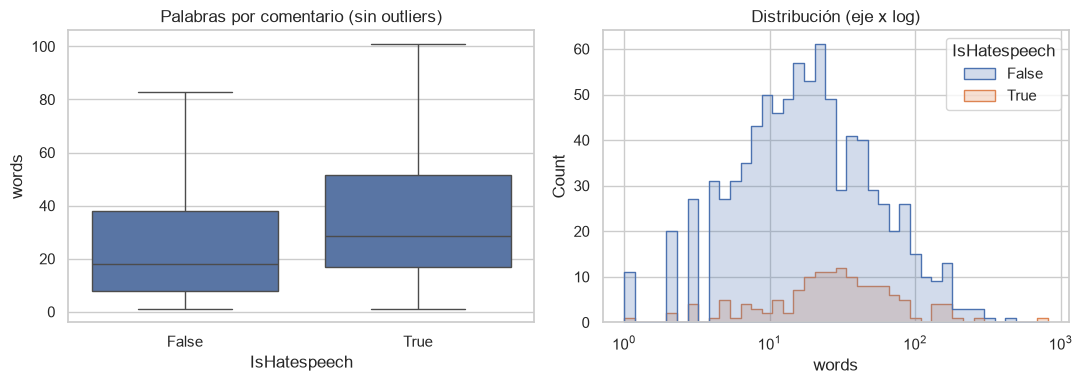

IsHatespeech
False    18.0
True     28.5
Name: words, dtype: float64


In [6]:
d = df.assign(chars=df[TEXT_COLUMN].str.len(), words=df[TEXT_COLUMN].str.split().str.len())
print(d[["chars","words"]].describe().round(1))
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(data=d, x=TARGET_COLUMN, y="words", ax=ax[0], showfliers=False); ax[0].set_title("Palabras por comentario (sin outliers)")
sns.histplot(data=d, x="words", hue=TARGET_COLUMN, bins=40, ax=ax[1], log_scale=(True, False), element="step"); ax[1].set_title("Distribución (eje x log)")
plt.tight_layout(); plt.show()
print(d.groupby(TARGET_COLUMN)["words"].median())

In [7]:
t = df[TEXT_COLUMN]
feat = {
 "contiene URL": t.str.contains(r"https?://|www\.", regex=True),
 "contiene @mención": t.str.contains(r"@\w+", regex=True),
 "caracteres no ASCII (emoji, acentos…)": t.apply(lambda s: any(ord(c) > 127 for c in s)),
 "palabras en MAYÚSCULAS (≥3 letras)": t.str.contains(r"\b[A-Z]{3,}\b", regex=True),
 "letras repetidas (loooove)": t.str.contains(r"(.)\1{2,}", regex=True),
 "menos de 5 palabras": t.str.split().str.len() < 5,
}
pd.DataFrame({"% comentarios": {k: round(v.mean()*100, 1) for k, v in feat.items()}})

,% comentarios
contiene URL,1.2
contiene @mención,0.5
"caracteres no ASCII (emoji, acentos…)",20.4
palabras en MAYÚSCULAS (≥3 letras),18.6
letras repetidas (loooove),21.3
menos de 5 palabras,9.7


**Lectura**: el texto es corto (mediana 19 palabras), con cola larga, y los comentarios de odio son
**más largos** (mediana 28.5 vs 18 palabras). Una parte apreciable (~20%) tiene
mayúsculas, letras repetidas o caracteres no ASCII: la limpieza con regex del proyecto tiene sentido, pero
también significa que hay señal (énfasis, mayúsculas) que la limpieza actual descarta.

## 4. Vocabulario: qué palabras distinguen el odio

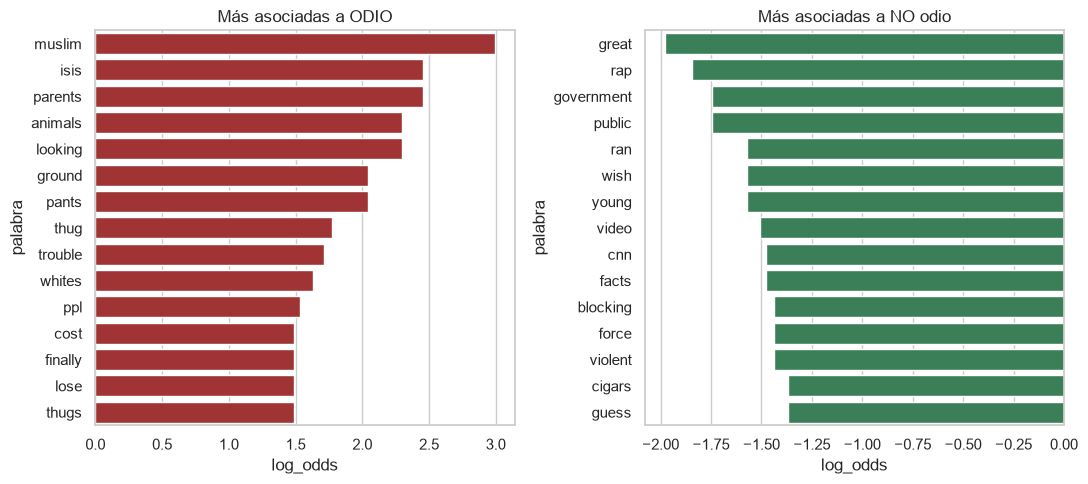

In [8]:
cv = CountVectorizer(stop_words="english", min_df=5, token_pattern=r"(?u)\b[a-zA-Z]{3,}\b", lowercase=True)
X = cv.fit_transform(df[TEXT_COLUMN]); vocab = np.array(cv.get_feature_names_out())
y = df[TARGET_COLUMN].values
pos = np.asarray(X[y].sum(0)).ravel() + 1; neg = np.asarray(X[~y].sum(0)).ravel() + 1
lo = np.log((pos / pos.sum()) / (neg / neg.sum()))
top = pd.DataFrame({"palabra": vocab, "log_odds": lo, "n_odio": pos-1, "n_no_odio": neg-1})
fig, ax = plt.subplots(1, 2, figsize=(11, 5))
sns.barplot(data=top.nlargest(15, "log_odds"), y="palabra", x="log_odds", ax=ax[0], color="firebrick"); ax[0].set_title("Más asociadas a ODIO")
sns.barplot(data=top.nsmallest(15, "log_odds"), y="palabra", x="log_odds", ax=ax[1], color="seagreen"); ax[1].set_title("Más asociadas a NO odio")
plt.tight_layout(); plt.show()

**Cuidado con la lectura**: si las palabras "de odio" son sobre todo términos de un tema concreto (etnia,
religión, un suceso) y no insultos, el modelo aprende *el tema del vídeo*, no el odio. Se comprueba en la sección 6.

## 5. Leer comentarios reales

In [9]:
print("=== 8 comentarios marcados como ODIO ===")
for s in df[df[TARGET_COLUMN]][TEXT_COLUMN].sample(8, random_state=1): print("-", s.replace("\n"," ")[:220])
print("\n=== 6 TÓXICOS pero NO odio (insulto sin componente identitario) ===")
sub = df[(df.IsToxic) & (~df[TARGET_COLUMN])][TEXT_COLUMN]
for s in sub.sample(6, random_state=1): print("-", s.replace("\n"," ")[:220])
print("\n=== 6 comentarios NO tóxicos (para contraste) ===")
for s in df[df[LABEL_COLUMNS].sum(axis=1) == 0][TEXT_COLUMN].sample(6, random_state=1): print("-", s.replace("\n"," ")[:220])

=== 8 comentarios marcados como ODIO ===
- That Arab is rapping 3:14 Go ahead bro....LOL So getto he is
- One feral hoodlum put down, the rest of us no longer need to fear his thuggish behavior. Upset about that? Blame his parents- they failed to raise him right and provide proper supervision. Or, he was just defective from 
- Right on!!! Finally some Sane opinion on this event! These Black bastards are soooooooooo IGNORANT!!! Running around yelling and looting and carrying on, just like in LA Riots.... Same old shit
- He looks ready to cut heads off he must be a isis sympathizer and I'm going to say maybe 5% care about the issue at hand and other 95% just want to go loot stores and fuck shit up...
- White man can't finish his sentence America needs to wake up!!the truth of murder is there!
- What's with all the dislikes? White people are that offended? You thought racism wasn't an issue anymore....think again
- They don't want justice.  Here you see a mob mentality in action.  He's gu

## 6. Efecto del vídeo

In [10]:
g = df.groupby(VIDEO_ID_COLUMN).agg(n=(TEXT_COLUMN, "size"), odio=(TARGET_COLUMN, "mean"), toxico=("IsToxic", "mean")).sort_values("n", ascending=False)
print(g.round(3))
tab = pd.crosstab(df[VIDEO_ID_COLUMN], df[TARGET_COLUMN])
chi2, p, *_ = chi2_contingency(tab)
print(f"\nChi² independencia vídeo vs odio: chi2={chi2:.1f}, p={p:.4f}")

               n   odio  toxico
VideoId                        
9pr1oE34bIM  274  0.117   0.321
04kJtp6pVXI  172  0.233   0.645
cT14IbTDW2c  143  0.091   0.734
dG7mZQvaQDk  112  0.098   0.196
TZxEyoplYbI  104  0.192   0.481
bUgKZMSxr3E   39  0.026   0.462
8HB18hZrhXc   38  0.105   0.605
4rCweDxDqdw   37  0.162   0.270
Dt9-byUhPdg   34  0.147   0.500
#NAME?        16  0.125   0.312
XRuCW80L9mA   10  0.200   0.200
dDbRyFIkNII   10  0.100   0.500
5vF4si3hoRA    8  0.125   0.375

Chi² independencia vídeo vs odio: chi2=25.8, p=0.0115


Con `p ≈ 0.01`, la tasa de odio **depende del vídeo** (de 2.6% a 23%): el modelo puede estar aprendiendo el
tema del vídeo. Además, los ejemplos apuntan a un único contexto (caso Ferguson / Michael Brown). Esto justifica reportar, además del split normal, un split que deje vídeos enteros fuera
(`video_holdout_split`).

## 7. Conclusiones y decisiones para el modelado

1. **Tamaño**: solo 138 positivos de odio. Es la limitación principal y explica el techo de F1 (~0.7 macro).
2. **Qué mide realmente el target**: etiquetas limpias y jerárquicas, pero el "odio" es 91% racismo y todo el
   corpus gira en torno a un mismo suceso. El modelo **no generalizará** a otros tipos de odio (sexismo,
   homofobia, religión) ni a otros temas: hay que decirlo explícitamente al cliente.
3. **Sesgo de tema/vídeo**: la tasa de odio varía por vídeo (chi², p≈0.01); hay que validar también con
   vídeos no vistos (`video_holdout_split`).
4. **Señal útil que la limpieza descarta o no usa**: longitud (odio ≈ +50% más largo), mayúsculas y letras
   repetidas. Candidatos a *features* extra.
5. **Acciones**: (a) validación cruzada repetida en lugar de un único test de 200 filas; (b) *data
   augmentation* de la clase de odio; (c) dataset externo con otros tipos de odio / transformer preentrenado.
